# dair-ai/emotion Dataset Training and Testing Notebook
This notebook downloads the **dair-ai/emotion** dataset from Hugging Face, saves the splits locally as CSVs under `data/`, maps emotion labels to sentiment classes (Negative, Neutral, Positive), and trains both classical and deep learning sentiment classification models.

## Setup & Imports

In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Append current directory to path to import local modules
sys.path.append(os.path.abspath('.'))
from models import TextModel

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


## 1. Download and Save Hugging Face dair-ai/emotion Dataset
We use Hugging Face's `datasets` library to load the dataset and save the train, validation, and test splits as CSV files under the `data/` directory.

In [2]:
from datasets import load_dataset

print("Downloading dair-ai/emotion dataset from Hugging Face...")
raw_dataset = load_dataset("dair-ai/emotion")

os.makedirs("data", exist_ok=True)
print("Saving splits locally to data/ directory...")
raw_dataset['train'].to_csv("data/dair_emotion_train.csv", index=False)
raw_dataset['validation'].to_csv("data/dair_emotion_validation.csv", index=False)
raw_dataset['test'].to_csv("data/dair_emotion_test.csv", index=False)

print("Download and save completed successfully!")

/Users/sumitkumar776693/Desktop/Project/Client/Sentimental-Analyses-Current/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving splits locally to data/ directory...


Creating CSV from Arrow format: 100%|██████████| 2/2 [00:00<00:00, 494.20ba/s]

Download and save completed successfully!


## 2. Load Local Data & Label Mapping
We load the CSV files we just saved. We map the dataset's emotion classes to 3 sentiment categories:
- `sadness` (0), `anger` (3), `fear` (4) -> `0` (Negative)
- `surprise` (5) -> `1` (Neutral)
- `joy` (1), `love` (2) -> `2` (Positive)

In [3]:
train_df = pd.read_csv("data/dair_emotion_train.csv")
val_df = pd.read_csv("data/dair_emotion_validation.csv")
test_df = pd.read_csv("data/dair_emotion_test.csv")

# Emotion mapping
label_mapping = {0: 0, 1: 2, 2: 2, 3: 0, 4: 0, 5: 1}

train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping)
test_df['label'] = test_df['label'].map(label_mapping)

print("Training label distribution:")
print(train_df['label'].value_counts())
train_df.head()

Training label distribution:
label
0    8762
2    6666
1     572
Name: count, dtype: int64


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,0


## 3. Text Preprocessing

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'&quot;', '"', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Remove empty values
train_df = train_df[train_df['clean_text'] != '']
val_df = val_df[val_df['clean_text'] != '']
test_df = test_df[test_df['clean_text'] != '']

## 4. Approach 1: Classical Machine Learning Baseline (TF-IDF + Logistic Regression)
We compute TF-IDF features and train a Logistic Regression model on the full training split.

In [5]:
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(train_df['clean_text'])
X_val_tfidf = vectorizer.transform(val_df['clean_text'])
X_test_tfidf = vectorizer.transform(test_df['clean_text'])

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_tfidf, train_df['label'])

val_preds = lr_model.predict(X_val_tfidf)
print(f"Validation Accuracy: {accuracy_score(val_df['label'], val_preds):.4f}")
print(classification_report(val_df['label'], val_preds, target_names=['Negative', 'Neutral', 'Positive']))

Training Logistic Regression...
Validation Accuracy: 0.9200
              precision    recall  f1-score   support

    Negative       0.90      0.97      0.93      1037
     Neutral       0.93      0.31      0.46        81
    Positive       0.94      0.92      0.93       882

    accuracy                           0.92      2000
   macro avg       0.92      0.73      0.78      2000
weighted avg       0.92      0.92      0.91      2000



## 5. Approach 2: Deep Learning Pipeline (BERT Embeddings + PyTorch `TextModel`)
We extract frozen embeddings using `distilbert-base-uncased` tokenizer and encoder for all splits, then train the PyTorch `TextModel` defined in the workspace's `models.py`.

In [6]:
from transformers import AutoTokenizer, AutoModel

print("Loading DistilBERT tokenizer and encoder model...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_backbone = AutoModel.from_pretrained('distilbert-base-uncased').to(device)
bert_backbone.eval()

def extract_embeddings(texts):
    emb_list = []
    batch_size = 64
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            tokens = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
            outputs = bert_backbone(**tokens)
            # Mean pool representation
            embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu()
            emb_list.append(embeddings)
    return torch.cat(emb_list, dim=0)

print("Extracting training embeddings...")
X_train_emb = extract_embeddings(train_df['clean_text'].tolist())
print("Extracting validation embeddings...")
X_val_emb = extract_embeddings(val_df['clean_text'].tolist())
print("Extracting test embeddings...")
X_test_emb = extract_embeddings(test_df['clean_text'].tolist())

print(f"Training Embeddings shape: {X_train_emb.shape}")

Loading DistilBERT tokenizer and encoder model...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8597.53it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting training embeddings...
Extracting validation embeddings...
Extracting test embeddings...
Training Embeddings shape: torch.Size([16000, 768])


In [7]:
train_dataset = TensorDataset(X_train_emb, torch.tensor(train_df['label'].tolist()))
val_dataset = TensorDataset(X_val_emb, torch.tensor(val_df['label'].tolist()))
test_dataset = TensorDataset(X_test_emb, torch.tensor(test_df['label'].tolist()))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Instantiate models
model = TextModel(pretrained_dim=768, feature_dim=256).to(device)
eval_classifier = nn.Linear(256, 3).to(device) # maps to 3 classes (0: Neg, 1: Neu, 2: Pos)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(model.parameters()) + list(eval_classifier.parameters()), lr=0.001)

epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Training deep learning model ===")
for epoch in range(epochs):
    model.train()
    eval_classifier.train()
    train_loss, correct, total = 0.0, 0, 0
    
    for batch_inputs, batch_labels in train_loader:
        batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        features = model(batch_inputs)
        logits = eval_classifier(features)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_inputs.size(0)
        _, predicted = logits.max(1)
        total += batch_labels.size(0)
        correct += predicted.eq(batch_labels).sum().item()
        
    epoch_loss = train_loss / total
    epoch_acc = correct / total
    
    # Validation
    model.eval()
    eval_classifier.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_inputs, batch_labels in val_loader:
            batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
            features = model(batch_inputs)
            logits = eval_classifier(features)
            loss = criterion(logits, batch_labels)
            
            val_loss += loss.item() * batch_inputs.size(0)
            _, predicted = logits.max(1)
            val_total += batch_labels.size(0)
            val_correct += predicted.eq(batch_labels).sum().item()
            
    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
    
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

=== Training deep learning model ===
Epoch 1/10 - Train Loss: 0.5108, Train Acc: 0.7900 | Val Loss: 0.4459, Val Acc: 0.8095
Epoch 2/10 - Train Loss: 0.4287, Train Acc: 0.8224 | Val Loss: 0.4290, Val Acc: 0.8260
Epoch 3/10 - Train Loss: 0.3966, Train Acc: 0.8311 | Val Loss: 0.4163, Val Acc: 0.8310
Epoch 4/10 - Train Loss: 0.3677, Train Acc: 0.8482 | Val Loss: 0.4162, Val Acc: 0.8310
Epoch 5/10 - Train Loss: 0.3417, Train Acc: 0.8554 | Val Loss: 0.4021, Val Acc: 0.8340
Epoch 6/10 - Train Loss: 0.3174, Train Acc: 0.8646 | Val Loss: 0.4229, Val Acc: 0.8290
Epoch 7/10 - Train Loss: 0.2935, Train Acc: 0.8773 | Val Loss: 0.4118, Val Acc: 0.8380
Epoch 8/10 - Train Loss: 0.2764, Train Acc: 0.8832 | Val Loss: 0.4169, Val Acc: 0.8335
Epoch 9/10 - Train Loss: 0.2544, Train Acc: 0.8919 | Val Loss: 0.4471, Val Acc: 0.8375
Epoch 10/10 - Train Loss: 0.2394, Train Acc: 0.9006 | Val Loss: 0.4521, Val Acc: 0.8330


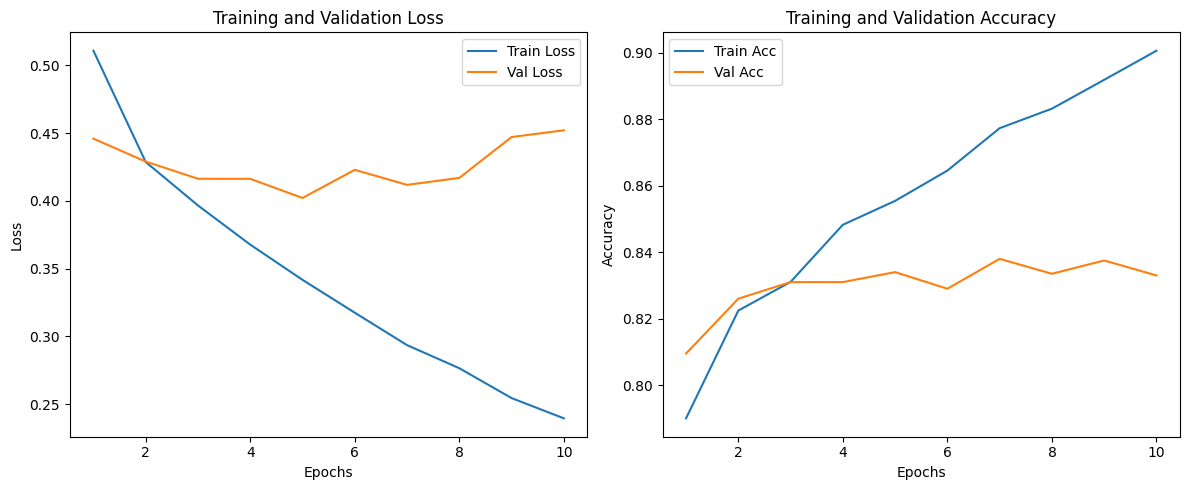

=== PyTorch TextModel Test Set Performance ===
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.87      1080
     Neutral       0.52      0.38      0.44        66
    Positive       0.86      0.81      0.83       854

    accuracy                           0.84      2000
   macro avg       0.74      0.69      0.71      2000
weighted avg       0.84      0.84      0.84      2000



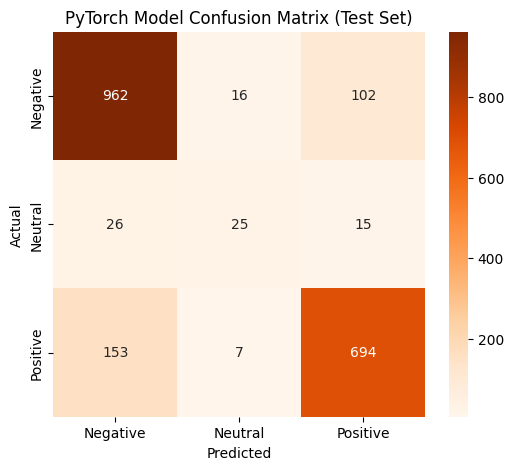

In [8]:
# Plotting
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Final Evaluation on test set
model.eval()
eval_classifier.eval()
test_preds = []
test_targets = []
with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device)
        features = model(batch_inputs)
        logits = eval_classifier(features)
        _, predicted = logits.max(1)
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(batch_labels.numpy())

print("=== PyTorch TextModel Test Set Performance ===")
print(classification_report(test_targets, test_preds, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
cm_dl = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('PyTorch Model Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Weights Export

In [9]:
os.makedirs('../weights', exist_ok=True)
weight_path = '../weights/text_model_emotion.pt'
torch.save(model.state_dict(), weight_path)
print(f"Successfully saved text model emotion weights to {weight_path}")

Successfully saved text model emotion weights to ../weights/text_model_emotion.pt
